In [1]:
import numpy as np
from scipy.linalg import expm, pinvh, LinAlgError
from scipy.special import comb
from scipy.integrate import *

import matplotlib.pyplot as plt

from electron_integrals import *
from CI_physicist import *

Define functions

In [2]:
# Function to get reduced density matrices

def get_RDMs(num_orbitals, num_electrons, C):
    slater_dets = CIHamiltonian.get_slater_dets(num_orbitals, num_electrons)
    C_conj = C.conj()

    D = np.zeros((num_orbitals,)*2 , dtype=np.cdouble)
    d = np.zeros((num_orbitals,)*4, dtype=np.cdouble)

    for n, det_n in enumerate(slater_dets):
        for m, det_m in enumerate(slater_dets):
            num_differences = np.sum(np.abs(det_n-det_m))
            match(num_differences):
                case 0:
                    for p, n_p in enumerate(det_n):
                        D[p,p] += n_p*C_conj[m]*C[n]
                        for r, n_r in enumerate(det_n):
                            d[p,r,p,r] += n_p*n_r*C_conj[m]*C[n]
                            d[p,r,r,p] -= n_p*n_r*C_conj[m]*C[n] # Note the sign                 
                case 2:
                    p = np.flatnonzero(np.asarray((det_m-det_n)==1))[0]
                    q = np.flatnonzero(np.asarray((det_n-det_m)==1))[0]
                    gamma = (-1)**(np.sum(det_n[:q])+np.sum(det_m[:p]))
                    D[p,q] += gamma*C_conj[m]*C[n]

                    for r, n_r in enumerate(det_n):
                        val = gamma*n_r*C_conj[m]*C[n]
                        d[p,r,q,r] += val
                        d[r,p,q,r] -= val # Note the sign
                        d[p,r,r,q] -= val # Note the sign
                        d[r,p,r,q] += val

                case 4:
                    p,q = np.flatnonzero(np.asarray((det_m-det_n)==1))
                    r,s = np.flatnonzero(np.asarray((det_n-det_m)==1))
                    
                    gamma = np.sum(det_n[:r])
                    gamma += np.sum(det_n[:s])-1 # -1 since r<s 
                    gamma += np.sum(det_n[:q])-int(s<q)-int(r<q)
                    gamma += np.sum(det_n[:p])-int(s<p)-int(r<p) # No additional term since p<q

                    val = C_conj[m]*C[n]*(-1)**gamma
                    d[p,q,r,s] += val
                    d[q,p,r,s] -= val # Note the sign
                    d[p,q,s,r] -= val # Note the sign
                    d[q,p,s,r] += val

    return D, d


# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 

def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
    num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

In [34]:
y = Cb_to_y(C_init, b_init)
C_test, b_test = y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
np.testing.assert_equal(C_init,C_test)
np.testing.assert_equal(b_init,b_test)

Define number of electrons and orbitals

In [3]:
# Number of orbitals (without spin)
num_orbitals = 21
# Number of electrons
num_electrons = 2
#Include spin?
include_spin = True
spin_factor = 1+int(include_spin)

num_spin_orbitals = spin_factor*num_orbitals

Calculate electron integrals

In [4]:
x_max = 10
num_points = 1000

x = np.linspace(-x_max,x_max,num_points)

#pot = GaussianWell(w=100, a=1, center=0)
pot = HOPotential()

spf, h = get_spf_and_diag_h(num_orbitals, x, pot)

if include_spin:
    #Add spin
    h = np.kron(h, np.eye(2,2))

g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.01)

if include_spin:
    #Add spin
    g = np.kron(g, np.einsum("pr,qs->pqrs",np.eye(2,2), np.eye(2,2)))

print('Sanity test, due to symmetry in g this should be zero:')
print(-g[2,1,1,0]+g[2,0,1,1]+g[1,1,2,0]-g[1,0,2,1])

Sanity test, due to symmetry in g this should be zero:
0.0


Solve using Slater-Condon 

In [5]:
g = np.zeros_like(g)

H = SlaterCondonHamiltonian(num_spin_orbitals, num_electrons, h, g).get_hamiltonian()
E_CI, C_CI = np.linalg.eigh(H)
print(E_CI)
#print(C_CI[:,0].T@H@C_CI[:,0])

#print(C_CI.conj().T@C_CI)

D, d = get_RDMs(num_spin_orbitals, num_electrons, C_CI[:,0])
E_rdm = np.einsum('pq, pq', D, h) + 0.5 * np.einsum('pqrs, pqrs', g, d)
print(E_rdm)

np.testing.assert_almost_equal(E_CI[0], E_rdm)


KeyboardInterrupt: 

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [6]:
num_mctdhf_orbitals = 4
num_mctdhf_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spin_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)

print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_slater_dets).astype(np.cdouble)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

C_init = np.zeros(num_mctdhf_slater_dets).astype(np.cdouble)
C_init[0] = 1

print(C_init)

[[ 2.34021460e-01+0.j -1.48389826e-01+0.j  4.36852260e-02+0.j
   2.63152510e-01+0.j]
 [ 1.93256746e-01+0.j  1.68218477e-01+0.j  2.15395428e-01+0.j
  -1.25042882e-01+0.j]
 [ 1.94766867e-01+0.j  2.36126524e-01+0.j -9.26845897e-02+0.j
   1.26968839e-01+0.j]
 [ 4.94382677e-02+0.j  6.38201442e-02+0.j -6.71705513e-02+0.j
   1.00276339e-01+0.j]
 [ 1.67955035e-01+0.j -1.88657694e-02+0.j -3.57932816e-05+0.j
  -8.22132713e-03+0.j]
 [-8.69499168e-03+0.j  8.96178419e-03+0.j  1.01729359e-01+0.j
  -8.14675853e-03+0.j]
 [ 7.78584895e-02+0.j  5.59665119e-02+0.j -7.25561927e-02+0.j
   9.77256284e-02+0.j]
 [ 1.33424922e-01+0.j -6.94505165e-02+0.j  2.31203330e-01+0.j
   1.76398694e-02+0.j]
 [ 2.82935966e-01+0.j -9.57042784e-03+0.j -6.36951945e-02+0.j
  -3.97749555e-02+0.j]
 [-5.48016782e-02+0.j  3.09840498e-01+0.j -3.17805717e-02+0.j
  -1.89272470e-02+0.j]
 [-8.16495460e-02+0.j  2.41579398e-01+0.j  1.44082543e-01+0.j
   7.43560992e-02+0.j]
 [ 3.28642632e-01+0.j -6.47847053e-03+0.j -1.00191251e-01+0.j
  -

Define callable class for the differential equations

In [7]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spin_orbitals = num_spin_orbitals
        self.num_electrons = num_electrons
        

    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spin_orbitals, self.num_electrons)
        bc = b.conj()

        h_1 = np.einsum('jm, ij -> im', b, self.h)
        h_2 = np.einsum('in, im -> nm', bc, h_1)
        h_3 = np.einsum('in, nm -> in', b, h_2)

        b_dot = -(h_1-h_3)


        H = SlaterCondonHamiltonian(self.num_mctdhf_orbitals, self.num_electrons, h_2, np.zeros((self.num_mctdhf_orbitals, )*4)).get_hamiltonian()

        E = C.conj().T@H@C/(C.conj().T@C)

        num_slater_dets = int(comb(num_mctdhf_orbitals, num_electrons))

        C_dot = np.zeros_like(C) #- (H-np.eye(num_slater_dets)*E)@C

        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [8]:
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
y_init = Cb_to_y(C_init, b_init)
t_init = 0
t_final = 30.0
solve_ivp(mctdhf_fun, [t_init, t_final], y_init, method = 'RK45')

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  4.662e-02 ...  2.076e+00  2.076e+00]
        y: [[1.00000000e+00+0.j 1.00000000e+00+0.j ... 1.00000000e+00+0.j
             1.00000000e+00+0.j]
            [0.00000000e+00+0.j 0.00000000e+00+0.j ... 0.00000000e+00+0.j
             0.00000000e+00+0.j]
            ...
            [4.10943963e-02+0.j 2.60434966e-02+0.j ... 1.51772583e-08+0.j
             1.51772586e-08+0.j]
            [2.17366202e-01+0.j 1.32984786e-01+0.j ... 2.92487886e-07+0.j
             2.92487883e-07+0.j]]
      sol: None
 t_events: None
 y_events: None
     nfev: 596
     njev: 0
      nlu: 0

In [9]:
#mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)

y_init = Cb_to_y(C_init, b_init)

Cs = np.copy(C_init).reshape(1,-1)

#H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()
Es = np.array([])

t_init = 0
t_final = 30.0
solver = DOP853(mctdhf_fun, t_init, y_init, t_final)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
    # Normalize every step during imaginary time prop
    #C = np.divide(C, np.sqrt(C.T.conj()@C))
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
  
    h_1 = np.einsum('jm, ij -> im', b, h)
    h_2 = np.einsum('in, im -> nm', b.conj(), h_1)
    h_3 = np.einsum('in, nm -> in', b, h_2)

    #b_dot = -1j*(h_1-h_3)

    #print(f'b_dot@b = \n{b.T.conj()@b_dot}')

    H = SlaterCondonHamiltonian(num_mctdhf_orbitals, num_electrons, h_2, np.zeros((num_mctdhf_orbitals, )*4)).get_hamiltonian()

    D, d = get_RDMs(num_mctdhf_orbitals, num_electrons, C)

    Es = np.append(Es, np.real(np.einsum('pq, pq', D, h_2)))
    #Es = np.append(Es, np.real(C.conj().T@H@C))
    Cs = np.append(Cs, C.reshape(1,-1), axis=0)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

[[ 7.71067432e-001+0.j -6.61525777e-001+0.j  1.98767276e-001+0.j
   9.03217050e-001+0.j]
 [ 6.36753496e-001+0.j  7.49922427e-001+0.j  9.80046718e-001+0.j
  -4.29184063e-001+0.j]
 [ 4.92954472e-014+0.j  1.02444383e-013+0.j -3.25903650e-014+0.j
   4.46354950e-014+0.j]
 [ 1.25128136e-014+0.j  2.76886102e-014+0.j -2.36189510e-014+0.j
   3.52518305e-014+0.j]
 [ 3.24066828e-027+0.j -7.97742991e-028+0.j -9.65276442e-031+0.j
  -2.96193726e-028+0.j]
 [-1.67768616e-028+0.j  3.78950912e-028+0.j  2.74344652e-027+0.j
  -2.93507207e-028+0.j]
 [ 1.13435126e-040+0.j  2.30880777e-040+0.j -1.48634675e-040+0.j
   3.60550373e-040+0.j]
 [ 1.94392069e-040+0.j -2.86506854e-040+0.j  4.73630583e-040+0.j
   6.50807940e-041+0.j]
 [ 3.07764685e-053+0.j -3.85259799e-054+0.j -9.79884063e-054+0.j
  -1.49863566e-053+0.j]
 [-5.96107362e-054+0.j  1.24727013e-052+0.j -4.88910913e-054+0.j
  -7.13138382e-054+0.j]
 [-6.54700402e-067+0.j  9.48170850e-066+0.j  1.64306125e-066+0.j
   2.84563868e-066+0.j]
 [ 2.63519485e-066+0.

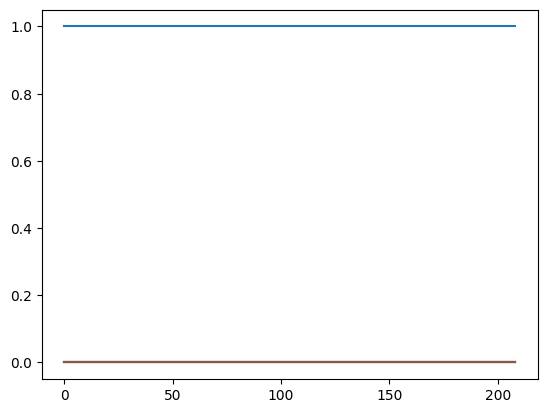

In [10]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spin_orbitals, num_electrons)
print(b_f)
print(C_f)
plt.plot(np.real(Cs))
plt.show()

0.9999749492973138


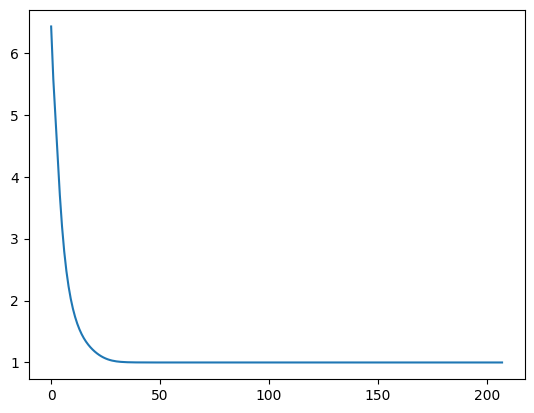

In [11]:
print(Es[-1])
plt.plot(Es)
plt.show()